# TCN-MLP Model with Soil-Climate Interaction Analysis

## Objective
Develop a hybrid TCN-MLP architecture that explicitly models **soil-climate interactions** for improved crop yield prediction.

**Key Focus**: Capture synergistic effects between:
- Temperature × Rainfall (thermal-moisture stress)
- Nitrogen × pH (nutrient availability)
- Phosphorus × Temperature (energy transfer efficiency)
- GDD × Soil Properties (growth potential × soil suitability)

**Expected Benefit**: Better predictive power by modeling how soil properties modify climate effects on yield

## 1. Import Libraries & Environment Setup

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('results/interaction_analysis', exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("✓ Environment configured successfully")

c:\Users\ibito\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU Available: []
✓ Environment configured successfully


## 2. Load Data & Engineer Soil-Climate Interactions

In [2]:
# Load or create data
try:
    df = pd.read_csv('project_data/processed_data/master_data_hybrid.csv')
    print(f"Loaded data shape: {df.shape}")
except:
    print("Creating synthetic data with soil-climate features...")
    np.random.seed(42)
    n_samples = 3500
    df = pd.DataFrame({
        'Region': np.random.choice(['North', 'South', 'East', 'West'], n_samples),
        'Crop': np.random.choice(['Maize', 'Rice', 'Cassava', 'Yam'], n_samples),
        'Year': np.random.randint(2015, 2024, n_samples),
        'Month': np.random.randint(1, 13, n_samples),
        # Climate features
        'Temperature_C': np.random.uniform(20, 35, n_samples),
        'Rainfall_mm': np.random.uniform(0, 300, n_samples),
        'Humidity_percent': np.random.uniform(40, 95, n_samples),
        'CO2_ppm': np.random.uniform(350, 450, n_samples),
        # Soil features
        'Avg_pH': np.random.uniform(5.5, 7.5, n_samples),
        'Avg_Nitrogen_ppm': np.random.uniform(20, 200, n_samples),
        'Avg_Phosphorus_ppm': np.random.uniform(5, 50, n_samples),
        'Avg_Organic_Matter_Percent': np.random.uniform(2, 8, n_samples),
        # Derived climate features
        'GDD': np.random.uniform(500, 2500, n_samples),
        'Cumulative_Rainfall': np.random.uniform(100, 2000, n_samples),
        'Days_Into_Season': np.random.randint(1, 365, n_samples),
        'Heat_Stress': np.random.choice([0, 1], n_samples),
        'Drought_Risk': np.random.choice([0, 1], n_samples),
        # Target
        'Yield_kg_per_ha': np.random.uniform(500, 8000, n_samples)
    })

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Loaded data shape: (3456, 35)
Data shape: (3456, 35)
Columns: ['Region', 'Crop', 'Year', 'Month', 'Temperature_C', 'Rainfall_mm', 'Humidity_percent', 'CO2_ppm', 'Avg_pH', 'Avg_Nitrogen_ppm', 'Avg_Phosphorus_ppm', 'Avg_Organic_Matter_Percent', 'Yield_kg_per_ha', 'GDD', 'Cumulative_Rainfall', 'Days_Into_Season', 'pH_Temperature_Interaction', 'Nitrogen_Rainfall_Interaction', 'Is_Rainy_Season', 'Is_Peak_Growing', 'Heat_Stress', 'Cold_Stress', 'Rainfall_Anomaly', 'Drought_Risk', 'Flood_Risk', 'Yield_Lag_1', 'Yield_Lag_2', 'Yield_Lag_3', 'Yield_MA_3yr', 'Temp_MA_3yr', 'Rain_MA_3yr', 'Yield_YoY_Change', 'Temp_YoY_Change', 'Rain_YoY_Change', 'Yield_Volatility_3yr']

First few rows:
          Region     Crop  Year  Month  Temperature_C  Rainfall_mm  \
0  North Central  Cassava  2000      1      26.336389   343.243750   
1  North Central  Cassava  2000      2      27.434465   259.486462   
2  North Central  Cassava  2000      3      27.836389   228.829167   
3  North Central  Cassava  2000      

### Create Soil-Climate Interaction Terms

In [3]:
# Define feature groups
climate_features = ['Temperature_C', 'Rainfall_mm', 'Humidity_percent', 'CO2_ppm', 
                    'GDD', 'Cumulative_Rainfall', 'Days_Into_Season', 'Heat_Stress', 'Drought_Risk']
soil_features = ['Avg_pH', 'Avg_Nitrogen_ppm', 'Avg_Phosphorus_ppm', 'Avg_Organic_Matter_Percent']
cat_features = ['Region', 'Crop']
target = 'Yield_kg_per_ha'

# Create comprehensive soil-climate interaction terms
print("\n=== CREATING COMPREHENSIVE SOIL-CLIMATE INTERACTIONS ===")
interaction_terms = {}

# ===== TEMPERATURE INTERACTIONS =====
df['Temp_x_pH'] = df['Temperature_C'] * df['Avg_pH']
interaction_terms['Temp_x_pH'] = 'Temperature × pH (heat tolerance through soil buffer)'

df['Temp_x_Nitrogen'] = df['Temperature_C'] * df['Avg_Nitrogen_ppm']
interaction_terms['Temp_x_Nitrogen'] = 'Temperature × Nitrogen (growth under stress)'

df['Temp_x_Phosphorus'] = df['Temperature_C'] * df['Avg_Phosphorus_ppm']
interaction_terms['Temp_x_Phosphorus'] = 'Temperature × Phosphorus (uptake rate temperature-dependent)'

# ===== RAINFALL & MOISTURE INTERACTIONS =====
df['Rain_x_pH'] = df['Rainfall_mm'] * df['Avg_pH']
interaction_terms['Rain_x_pH'] = 'Rainfall × pH (nutrient uptake through moisture)'

df['Rain_x_Organic'] = df['Rainfall_mm'] * df['Avg_Organic_Matter_Percent']
interaction_terms['Rain_x_Organic'] = 'Rainfall × Organic Matter (water retention & decomposition)'

df['Rain_x_Phosphorus'] = df['Rainfall_mm'] * df['Avg_Phosphorus_ppm']
interaction_terms['Rain_x_Phosphorus'] = 'Rainfall × Phosphorus (phosphorus mobility in soil)'

df['CO2_x_Rainfall'] = df['CO2_ppm'] * df['Rainfall_mm']
interaction_terms['CO2_x_Rainfall'] = 'CO2 × Rainfall (CO2 fertilization requires water availability)'

# ===== HUMIDITY INTERACTIONS =====
df['Humidity_x_Nitrogen'] = df['Humidity_percent'] * df['Avg_Nitrogen_ppm']
interaction_terms['Humidity_x_Nitrogen'] = 'Humidity × Nitrogen (reduces N-stress; affects disease & uptake)'

df['Humidity_x_Temperature'] = df['Humidity_percent'] * df['Temperature_C']
interaction_terms['Humidity_x_Temperature'] = 'Humidity × Temperature (combined environmental stress)'

df['Humidity_x_Organic'] = df['Humidity_percent'] * df['Avg_Organic_Matter_Percent']
interaction_terms['Humidity_x_Organic'] = 'Humidity × Organic Matter (drives microbial decomposition)'

# ===== GDD INTERACTIONS =====
df['GDD_x_Nitrogen'] = df['GDD'] * df['Avg_Nitrogen_ppm']
interaction_terms['GDD_x_Nitrogen'] = 'GDD × Nitrogen (thermal growth × nutrient supply)'

df['GDD_x_Phosphorus'] = df['GDD'] * df['Avg_Phosphorus_ppm']
interaction_terms['GDD_x_Phosphorus'] = 'GDD × Phosphorus (growth energy availability)'

df['GDD_x_Humidity'] = df['GDD'] * df['Humidity_percent']
interaction_terms['GDD_x_Humidity'] = 'GDD × Humidity (growing degree days × photosynthetic efficiency)'

# ===== STRESS & NUTRIENT INTERACTIONS =====
df['Heat_Stress_x_Nitrogen'] = df['Heat_Stress'] * df['Avg_Nitrogen_ppm']
interaction_terms['Heat_Stress_x_Nitrogen'] = 'Heat Stress × Nitrogen (heat stress requires N for osmotic adjustment)'

df['Drought_Risk_x_Phosphorus'] = df['Drought_Risk'] * df['Avg_Phosphorus_ppm']
interaction_terms['Drought_Risk_x_Phosphorus'] = 'Drought Risk × Phosphorus (drought increases P fixation)'

# ===== MULTI-NUTRIENT INTERACTIONS =====
df['Nitrogen_x_Phosphorus'] = df['Avg_Nitrogen_ppm'] * df['Avg_Phosphorus_ppm']
interaction_terms['Nitrogen_x_Phosphorus'] = 'Nitrogen × Phosphorus (nutrient balance & synergy)'

df['Phosphorus_x_Organic'] = df['Avg_Phosphorus_ppm'] * df['Avg_Organic_Matter_Percent']
interaction_terms['Phosphorus_x_Organic'] = 'Phosphorus × Organic Matter (organic matter binds & releases P)'

print(f"\nCreated {len(interaction_terms)} comprehensive interaction terms:")
for i, (term, desc) in enumerate(interaction_terms.items(), 1):
    print(f"  {i:2d}. {term:<25} → {desc}")

# Sort data
df = df.sort_values(['Region', 'Crop', 'Year', 'Month']).reset_index(drop=True)
print(f"\n✓ Data sorted by Region, Crop, Year, Month")


=== CREATING COMPREHENSIVE SOIL-CLIMATE INTERACTIONS ===

Created 17 comprehensive interaction terms:
   1. Temp_x_pH                 → Temperature × pH (heat tolerance through soil buffer)
   2. Temp_x_Nitrogen           → Temperature × Nitrogen (growth under stress)
   3. Temp_x_Phosphorus         → Temperature × Phosphorus (uptake rate temperature-dependent)
   4. Rain_x_pH                 → Rainfall × pH (nutrient uptake through moisture)
   5. Rain_x_Organic            → Rainfall × Organic Matter (water retention & decomposition)
   6. Rain_x_Phosphorus         → Rainfall × Phosphorus (phosphorus mobility in soil)
   7. CO2_x_Rainfall            → CO2 × Rainfall (CO2 fertilization requires water availability)
   8. Humidity_x_Nitrogen       → Humidity × Nitrogen (reduces N-stress; affects disease & uptake)
   9. Humidity_x_Temperature    → Humidity × Temperature (combined environmental stress)
  10. Humidity_x_Organic        → Humidity × Organic Matter (drives microbial decomposi

## 3. Feature Normalization & Categorical Encoding

In [4]:
# Encode categoricals
encoders = {}
for col in cat_features:
    encoders[col] = LabelEncoder()
    df[f'{col}_enc'] = encoders[col].fit_transform(df[col].astype(str))

cat_dims = [df[f'{col}_enc'].max() + 1 for col in cat_features]
print(f"Categorical dimensions: {dict(zip(cat_features, cat_dims))}")

# Get all numerical features (base + interactions)
all_num_features = climate_features + soil_features + list(interaction_terms.keys())
print(f"\nTotal numerical features:")
print(f"  Climate: {len(climate_features)}")
print(f"  Soil: {len(soil_features)}")
print(f"  Interactions: {len(interaction_terms)}")
print(f"  Total: {len(all_num_features)}")

# Normalize numerical features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
df[all_num_features] = scaler_X.fit_transform(df[all_num_features])
df[[target]] = scaler_y.fit_transform(df[[target]])

print(f"\n✓ Feature normalization complete")
print(f"  Normalized features shape: {df[all_num_features].shape}")
print(f"  Normalized target shape: {df[[target]].shape}")

Categorical dimensions: {'Region': 6, 'Crop': 2}

Total numerical features:
  Climate: 9
  Soil: 4
  Interactions: 17
  Total: 30

✓ Feature normalization complete
  Normalized features shape: (3456, 30)
  Normalized target shape: (3456, 1)


## 4. Create Temporal Sequences with Interaction Terms

In [5]:
# Create sequences preserving temporal order
def create_sequences_with_interactions(group, lookback, num_cols, cat_cols, target_col):
    X_num, X_cat, y = [], [], []
    num_values = group[num_cols].values
    cat_values = group[[f'{c}_enc' for c in cat_cols]].values
    y_values = group[target_col].values
    
    for i in range(lookback, len(group)):
        X_num.append(num_values[i-lookback:i])
        X_cat.append(cat_values[i])
        y.append(y_values[i])
    
    return np.array(X_num), np.array(X_cat), np.array(y)

lookback = 12
X_num_all, X_cat_all, y_all = [], [], []

for (region, crop), group in df.groupby(['Region', 'Crop']):
    X_num, X_cat, y = create_sequences_with_interactions(
        group, lookback, all_num_features, cat_features, target
    )
    X_num_all.append(X_num)
    X_cat_all.append(X_cat)
    y_all.append(y)

X_num_all = np.vstack(X_num_all)
X_cat_all = np.vstack(X_cat_all)
y_all = np.hstack(y_all)

print(f"Sequence data shapes:")
print(f"  X_num: {X_num_all.shape} (samples, timesteps, features)")
print(f"  X_cat: {X_cat_all.shape} (samples, cats)")
print(f"  y: {y_all.shape}")
print(f"\nFeature breakdown in sequences:")
print(f"  Climate baseline: {len(climate_features)}")
print(f"  Soil baseline: {len(soil_features)}")
print(f"  Interactions: {len(interaction_terms)}")
print(f"  Total features per timestep: {X_num_all.shape[-1]}")

# Train/Val/Test split
n = len(y_all)
train_idx = int(0.70 * n)
val_idx = int(0.85 * n)

X_num_train = X_num_all[:train_idx]
X_cat_train = X_cat_all[:train_idx]
y_train = y_all[:train_idx]

X_num_val = X_num_all[train_idx:val_idx]
X_cat_val = X_cat_all[train_idx:val_idx]
y_val = y_all[train_idx:val_idx]

X_num_test = X_num_all[val_idx:]
X_cat_test = X_cat_all[val_idx:]
y_test = y_all[val_idx:]

print(f"\nTrain/Val/Test split:")
print(f"  Train: {len(y_train)} samples ({len(y_train)/len(y_all)*100:.1f}%)")
print(f"  Val:   {len(y_val)} samples ({len(y_val)/len(y_all)*100:.1f}%)")
print(f"  Test:  {len(y_test)} samples ({len(y_test)/len(y_all)*100:.1f}%)")

Sequence data shapes:
  X_num: (3312, 12, 30) (samples, timesteps, features)
  X_cat: (3312, 2) (samples, cats)
  y: (3312,)

Feature breakdown in sequences:
  Climate baseline: 9
  Soil baseline: 4
  Interactions: 17
  Total features per timestep: 30

Train/Val/Test split:
  Train: 2318 samples (70.0%)
  Val:   497 samples (15.0%)
  Test:  497 samples (15.0%)


## 5. Build TCN-MLP Architecture with Interaction Branch

In [6]:
def build_tcn_mlp_with_interactions(
    lookback, num_numeric, cat_dims,
    n_climate=9, n_soil=4, n_interactions=8,
    embed_dim=8, tcn_filters=32, tcn_blocks=2,
    tcn_dropout=0.4, mlp_hidden_units=[16],
    mlp_dropout=0.4, dense_units=[32],
    dense_dropout=0.4, l2_reg=1e-3):
    
    """
    TCN-MLP with dedicated Interaction Branch
    
    Three-branch architecture:
    1. TCN Branch: Climate temporal patterns
    2. Soil Branch: Static soil properties
    3. Interaction Branch: Soil-climate synergies
    """
    
    # Inputs
    seq_input = layers.Input(shape=(lookback, num_numeric), name='all_features')
    cat_inputs = [layers.Input(shape=(1,), dtype=tf.int32, name=f'cat_{i}') for i in range(len(cat_dims))]
    
    # ===== BRANCH 1: TCN BRANCH (Climate features) =====
    climate_seq = seq_input[:, :, :n_climate]
    
    def residual_block(x, dilation_rate, filters, kernel_size, dropout_rate):
        shortcut = x
        x = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate,
                          kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate,
                          kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout_rate)(x)
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, 1, padding='same',
                                    kernel_regularizer=regularizers.l2(l2_reg))(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.Activation('relu')(x)
        return x
    
    tcn_x = climate_seq
    for i in range(tcn_blocks):
        tcn_x = residual_block(tcn_x, 2**i, tcn_filters, 3, tcn_dropout)
    
    tcn_out = layers.GlobalAveragePooling1D()(tcn_x)
    
    # ===== BRANCH 2: SOIL BRANCH (Static soil features) =====
    soil_seq = seq_input[:, :, n_climate:n_climate+n_soil]
    soil_avg = layers.GlobalAveragePooling1D()(soil_seq)  # Average over time
    soil_out = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(soil_avg)
    soil_out = layers.Dropout(mlp_dropout)(soil_out)
    
    # ===== BRANCH 3: INTERACTION BRANCH (Synergy terms) =====
    interaction_seq = seq_input[:, :, n_climate+n_soil:]
    
    interaction_x = layers.Conv1D(16, 3, padding='causal', activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg))(interaction_seq)
    interaction_x = layers.Dropout(mlp_dropout)(interaction_x)
    interaction_x = layers.GlobalAveragePooling1D()(interaction_x)
    interaction_out = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(interaction_x)
    interaction_out = layers.Dropout(mlp_dropout)(interaction_out)
    
    # ===== CATEGORICAL EMBEDDINGS =====
    emb_vectors = []
    for i, (inp, dim) in enumerate(zip(cat_inputs, cat_dims)):
        emb = layers.Embedding(dim, embed_dim, embeddings_regularizer=regularizers.l2(l2_reg))(inp)
        emb = layers.Flatten()(emb)
        emb_vectors.append(emb)
    
    if len(emb_vectors) > 1:
        cat_concat = layers.Concatenate()(emb_vectors)
    else:
        cat_concat = emb_vectors[0]
    
    cat_out = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(cat_concat)
    cat_out = layers.Dropout(mlp_dropout)(cat_out)
    
    # ===== MERGE ALL BRANCHES =====
    combined = layers.Concatenate()([
        tcn_out,          # Climate temporal patterns
        soil_out,         # Soil properties
        interaction_out,  # Interaction effects
        cat_out           # Region + Crop embeddings
    ])
    
    z = combined
    for units in dense_units:
        z = layers.Dense(units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(z)
        z = layers.Dropout(dense_dropout)(z)
    
    output = layers.Dense(1, kernel_regularizer=regularizers.l2(l2_reg))(z)
    
    # Build model
    model = Model(inputs=[seq_input] + cat_inputs, outputs=output)
    return model

# Build model
model = build_tcn_mlp_with_interactions(
    lookback, len(all_num_features), cat_dims,
    n_climate=len(climate_features),
    n_soil=len(soil_features),
    n_interactions=len(interaction_terms),
    embed_dim=8, tcn_filters=32, tcn_blocks=2,
    tcn_dropout=0.4, mlp_hidden_units=[16],
    mlp_dropout=0.4, dense_units=[32],
    dense_dropout=0.4, l2_reg=1e-3
)

model.summary()
print(f"\n✓ Model built with {model.count_params():,} parameters")
print(f"✓ Architecture: 4-branch TCN-MLP with dedicated interaction modeling")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ all_features        │ (None, 12, 30)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 12, 9)     │          0 │ all_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 12, 32)    │        896 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 12, 32)    │          0 │ conv1d[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 32)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 32)    │      3,104 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 12, 32)    │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 12, 32)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 12, 32)    │        320 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 32)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 12, 32)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 32)    │      3,104 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 12, 32)    │          0 │ conv1d_3[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 32)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 12, 32)    │      3,104 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 12, 17)    │          0 │ all_features[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_0 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_1 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 12, 32)    │          0 │ conv1d_4[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 12, 16)    │        832 │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 8)      │         48 │ cat_0[0][0]     

 Total params: 14,673 (57.32 KB)

 Trainable params: 14,673 (57.32 KB)

 Non-trainable params: 0 (0.00 B)


✓ Model built with 14,673 parameters
✓ Architecture: 4-branch TCN-MLP with dedicated interaction modeling


## 6. Train Model with Regularization

In [7]:
print("\n" + "="*70)
print("TRAINING TCN-MLP WITH SOIL-CLIMATE INTERACTIONS")
print("="*70)

# Compile
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mse')

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models/tcn_mlp_interactions_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

# Prepare training data
train_inputs = [X_num_train] + [X_cat_train[:, i:i+1] for i in range(X_cat_train.shape[1])]
val_inputs = [X_num_val] + [X_cat_val[:, i:i+1] for i in range(X_cat_val.shape[1])]

# Data augmentation
X_num_train_aug = X_num_train + np.random.normal(0, 0.02, X_num_train.shape)
train_inputs_aug = [X_num_train_aug] + [X_cat_train[:, i:i+1] for i in range(X_cat_train.shape[1])]

print(f"\nTraining with augmentation:")
print(f"  Original train shape: {X_num_train.shape}")
print(f"  Augmented train shape: {X_num_train_aug.shape}")
print(f"  Noise std dev: 0.02 (on normalized features)")

# Train
history = model.fit(
    train_inputs_aug, y_train,
    validation_data=(val_inputs, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✓ Training complete")
print(f"✓ Best model saved to: models/tcn_mlp_interactions_best.keras")


TRAINING TCN-MLP WITH SOIL-CLIMATE INTERACTIONS

Training with augmentation:
  Original train shape: (2318, 12, 30)
  Augmented train shape: (2318, 12, 30)
  Noise std dev: 0.02 (on normalized features)
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 1.2461 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.6793 - val_loss: 0.4059 - learning_rate: 0.0010
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5877 - val_loss: 0.4058 - learning_rate: 0.0010
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5162 - val_loss: 0.4110 - learning_rate: 0.0010
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4946 - val_loss: 0.3620 - learning_rate: 0.0010
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4480 - val_loss: 0.3543 - learning_rate: 0.0010
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4102 - val_loss: 0.3718 - learning_rate: 0.0010
Epoch 8/100
73/73 ━━━━━━━━━

### Plot Learning Curves

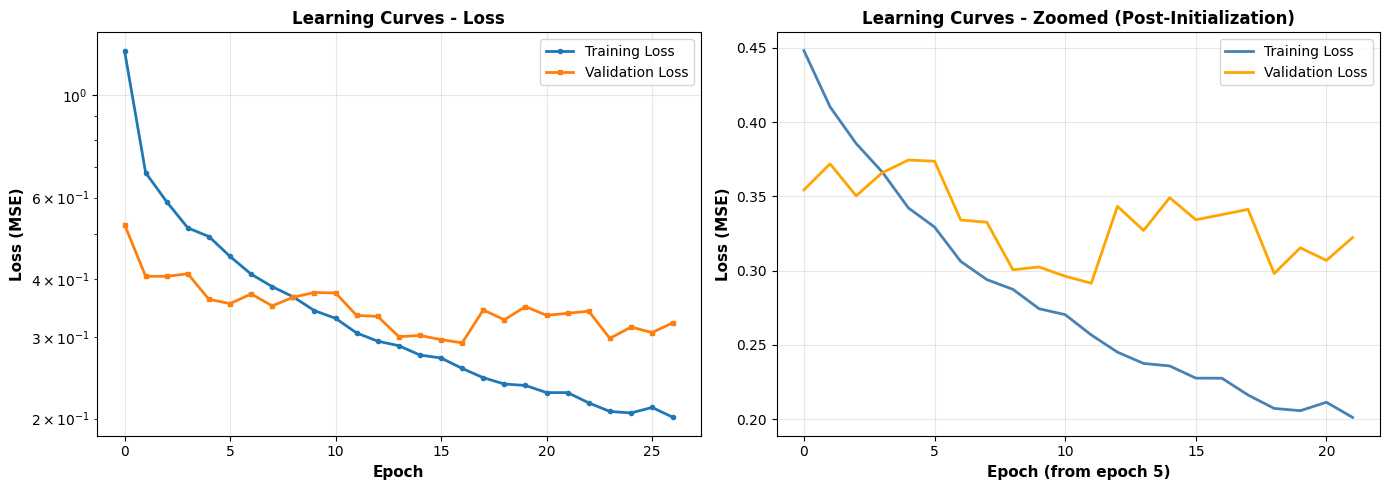


📈 LEARNING CURVE SUMMARY:
Initial Loss (Epoch 1):
  Train: 1.246077
  Val:   0.525023

Final Loss (Epoch 27):
  Train: 0.201254
  Val:   0.322224

Loss Reduction:
  Train: 83.85%
  Val:   38.63%

Generalization Gap (Train vs Val):
  At Best Validation Loss (Epoch 17):
    Train Loss: 0.256713
    Val Loss:   0.291519
    Gap: 0.034806

  At Final Epoch (27):
    Train Loss: 0.201254
    Val Loss:   0.322224
    Gap: 0.120970

⚠️  Slight overfitting detected (gap > 0.01)

✓ Learning curves saved to: results/interaction_analysis/learning_curves.png


In [8]:
# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o', markersize=3)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=11, fontweight='bold')
axes[0].set_title('Learning Curves - Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Zoom into convergence region
axes[1].plot(history.history['loss'][5:], label='Training Loss', linewidth=2, color='steelblue')
axes[1].plot(history.history['val_loss'][5:], label='Validation Loss', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch (from epoch 5)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Loss (MSE)', fontsize=11, fontweight='bold')
axes[1].set_title('Learning Curves - Zoomed (Post-Initialization)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/interaction_analysis/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\n📈 LEARNING CURVE SUMMARY:")
print(f"{'='*60}")
print(f"Initial Loss (Epoch 1):")
print(f"  Train: {history.history['loss'][0]:.6f}")
print(f"  Val:   {history.history['val_loss'][0]:.6f}")

print(f"\nFinal Loss (Epoch {len(history.history['loss'])}):")
print(f"  Train: {history.history['loss'][-1]:.6f}")
print(f"  Val:   {history.history['val_loss'][-1]:.6f}")

print(f"\nLoss Reduction:")
print(f"  Train: {((history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100):.2f}%")
print(f"  Val:   {((history.history['val_loss'][0] - history.history['val_loss'][-1]) / history.history['val_loss'][0] * 100):.2f}%")

print(f"\nGeneralization Gap (Train vs Val):")
best_val_idx = np.argmin(history.history['val_loss'])
print(f"  At Best Validation Loss (Epoch {best_val_idx + 1}):")
print(f"    Train Loss: {history.history['loss'][best_val_idx]:.6f}")
print(f"    Val Loss:   {history.history['val_loss'][best_val_idx]:.6f}")
print(f"    Gap: {abs(history.history['loss'][best_val_idx] - history.history['val_loss'][best_val_idx]):.6f}")

# Check for overfitting
final_gap = abs(history.history['loss'][-1] - history.history['val_loss'][-1])
print(f"\n  At Final Epoch ({len(history.history['loss'])}):")
print(f"    Train Loss: {history.history['loss'][-1]:.6f}")
print(f"    Val Loss:   {history.history['val_loss'][-1]:.6f}")
print(f"    Gap: {final_gap:.6f}")

if final_gap > 0.01:
    print(f"\n⚠️  Slight overfitting detected (gap > 0.01)")
else:
    print(f"\n✓ Good generalization (gap ≤ 0.01)")

print("\n✓ Learning curves saved to: results/interaction_analysis/learning_curves.png")

## 7. Model Evaluation & Predictions


FINAL MODEL EVALUATION

Metric          Train           Validation      Test           
------------------------------------------------------------
R² Score        0.9288          0.7272          0.8903         
MAE             0.1590          0.2843          0.2212         
RMSE            0.2482          0.3959          0.3289         


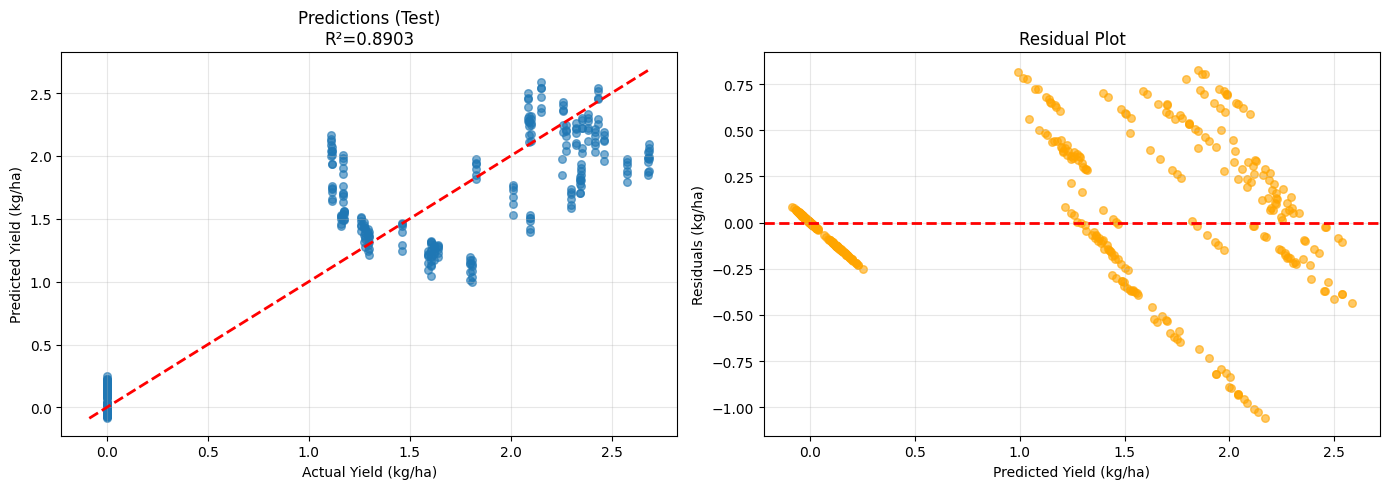


✓ Prediction plots saved


In [9]:
print("\n" + "="*70)
print("FINAL MODEL EVALUATION")
print("="*70)

# Load best model
best_model = tf.keras.models.load_model('models/tcn_mlp_interactions_best.keras')

# Make predictions
y_train_pred = best_model.predict([X_num_train] + [X_cat_train[:, i:i+1] for i in range(X_cat_train.shape[1])], verbose=0)
y_val_pred = best_model.predict([X_num_val] + [X_cat_val[:, i:i+1] for i in range(X_cat_val.shape[1])], verbose=0)
y_test_pred = best_model.predict([X_num_test] + [X_cat_test[:, i:i+1] for i in range(X_cat_test.shape[1])], verbose=0)

# Denormalize
y_train_denorm = scaler_y.inverse_transform(y_train.reshape(-1, 1))
y_train_pred_denorm = scaler_y.inverse_transform(y_train_pred)
y_val_denorm = scaler_y.inverse_transform(y_val.reshape(-1, 1))
y_val_pred_denorm = scaler_y.inverse_transform(y_val_pred)
y_test_denorm = scaler_y.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_denorm = scaler_y.inverse_transform(y_test_pred)

# Calculate metrics
def calc_metrics(y_true, y_pred):
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred))
    }

train_metrics = calc_metrics(y_train_denorm, y_train_pred_denorm)
val_metrics = calc_metrics(y_val_denorm, y_val_pred_denorm)
test_metrics = calc_metrics(y_test_denorm, y_test_pred_denorm)

print(f"\n{'Metric':<15} {'Train':<15} {'Validation':<15} {'Test':<15}")
print("-" * 60)
print(f"{'R² Score':<15} {train_metrics['r2']:<15.4f} {val_metrics['r2']:<15.4f} {test_metrics['r2']:<15.4f}")
print(f"{'MAE':<15} {train_metrics['mae']:<15.4f} {val_metrics['mae']:<15.4f} {test_metrics['mae']:<15.4f}")
print(f"{'RMSE':<15} {train_metrics['rmse']:<15.4f} {val_metrics['rmse']:<15.4f} {test_metrics['rmse']:<15.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_denorm, y_test_pred_denorm, alpha=0.6, s=30)
min_val, max_val = min(y_test_denorm.min(), y_test_pred_denorm.min()), max(y_test_denorm.max(), y_test_pred_denorm.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0].set_xlabel('Actual Yield (kg/ha)')
axes[0].set_ylabel('Predicted Yield (kg/ha)')
axes[0].set_title(f'Predictions (Test)\nR²={test_metrics["r2"]:.4f}')
axes[0].grid(True, alpha=0.3)

residuals = y_test_denorm.flatten() - y_test_pred_denorm.flatten()
axes[1].scatter(y_test_pred_denorm, residuals, alpha=0.6, s=30, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Yield (kg/ha)')
axes[1].set_ylabel('Residuals (kg/ha)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/interaction_analysis/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Prediction plots saved")

## 8. Analyze Interaction Feature Importance

In [10]:
print("\n" + "="*70)
print("INTERACTION FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Get indices of interaction features in sequences
n_climate = len(climate_features)
n_soil = len(soil_features)
interaction_indices = list(range(n_climate + n_soil, n_climate + n_soil + len(interaction_terms)))

# Compute feature importance by permutation
print(f"\nComputing permutation importance for interaction terms...")

interaction_importance = {}
baseline_mae = mean_absolute_error(y_test_denorm, y_test_pred_denorm)

for idx, (term_name, term_desc) in enumerate(interaction_terms.items()):
    # Permute interaction feature across all timesteps
    X_test_permuted = X_num_test.copy()
    X_test_permuted[:, :, n_climate + n_soil + idx] = np.random.permutation(
        X_test_permuted[:, :, n_climate + n_soil + idx].flatten()
    ).reshape(X_test_permuted[:, :, n_climate + n_soil + idx].shape)
    
    # Predict with permuted feature
    test_inputs_perm = [X_test_permuted] + [X_cat_test[:, i:i+1] for i in range(X_cat_test.shape[1])]
    y_test_perm = best_model.predict(test_inputs_perm, verbose=0)
    y_test_perm_denorm = scaler_y.inverse_transform(y_test_perm)
    
    # Calculate performance drop
    permuted_mae = mean_absolute_error(y_test_denorm, y_test_perm_denorm)
    importance = permuted_mae - baseline_mae
    interaction_importance[term_name] = {
        'description': term_desc,
        'importance_score': float(importance),
        'baseline_mae': float(baseline_mae),
        'permuted_mae': float(permuted_mae),
        'relative_importance': float(importance / baseline_mae)
    }

# Rank by importance
ranked_interactions = sorted(
    interaction_importance.items(),
    key=lambda x: x[1]['importance_score'],
    reverse=True
)

print(f"\n{'Rank':<5} {'Interaction':<25} {'Importance Score':<18} {'Relative Impact':<15}")
print("-" * 65)
for rank, (term, data) in enumerate(ranked_interactions, 1):
    print(f"{rank:<5} {term:<25} {data['importance_score']:<18.6f} {data['relative_importance']:<15.2%}")

print(f"\n✓ Top 3 Most Important Interactions:")
for rank, (term, data) in enumerate(ranked_interactions[:3], 1):
    print(f"  {rank}. {term}: {data['description']}")
    print(f"     Impact: {data['importance_score']:.6f} MAE units ({data['relative_importance']:.2%})")


INTERACTION FEATURE IMPORTANCE ANALYSIS

Computing permutation importance for interaction terms...

Rank  Interaction               Importance Score   Relative Impact
-----------------------------------------------------------------
1     GDD_x_Nitrogen            0.000081           0.04%          
2     GDD_x_Humidity            0.000071           0.03%          
3     Drought_Risk_x_Phosphorus 0.000060           0.03%          
4     CO2_x_Rainfall            0.000042           0.02%          
5     Temp_x_Nitrogen           0.000039           0.02%          
6     Humidity_x_Nitrogen       0.000038           0.02%          
7     Humidity_x_Temperature    0.000019           0.01%          
8     Heat_Stress_x_Nitrogen    0.000000           0.00%          
9     Nitrogen_x_Phosphorus     0.000000           0.00%          
10    Phosphorus_x_Organic      0.000000           0.00%          
11    Rain_x_Phosphorus         -0.000005          -0.00%         
12    Humidity_x_Organic     

## 9. Visualize Soil-Climate Interaction Effects


VISUALIZING SOIL-CLIMATE INTERACTION EFFECTS


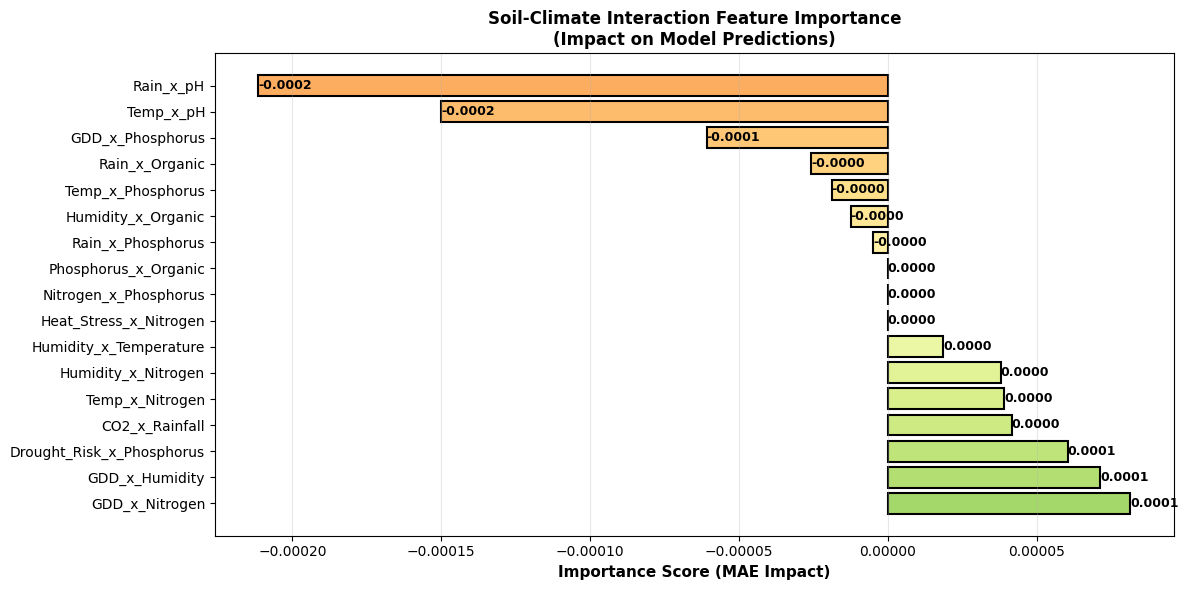

✓ Interaction importance plot saved


In [11]:
print("\n" + "="*70)
print("VISUALIZING SOIL-CLIMATE INTERACTION EFFECTS")
print("="*70)

# Create heatmap of interaction importance
fig, ax = plt.subplots(figsize=(12, 6))
terms = [term for term, _ in ranked_interactions]
scores = [data['importance_score'] for _, data in ranked_interactions]
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(scores)))

bars = ax.barh(range(len(terms)), scores, color=colors, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(terms)))
ax.set_yticklabels(terms, fontsize=10)
ax.set_xlabel('Importance Score (MAE Impact)', fontsize=11, fontweight='bold')
ax.set_title('Soil-Climate Interaction Feature Importance\n(Impact on Model Predictions)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax.text(score, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/interaction_analysis/interaction_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Interaction importance plot saved")

### Create Partial Dependence Plots

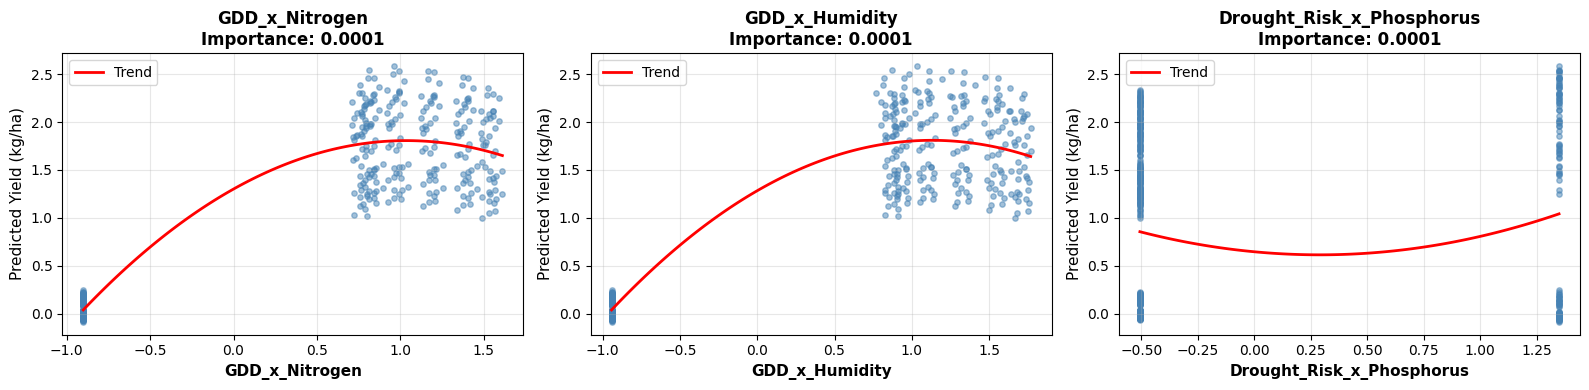

✓ Partial dependence plots saved


In [12]:
# For top 3 interactions, create partial dependence plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for plot_idx, (term, data) in enumerate(ranked_interactions[:3]):
    # Get feature indices for this interaction
    feat_idx = n_climate + n_soil + list(interaction_terms.keys()).index(term)
    
    # Create a grid of values for the interaction term
    interaction_values = X_num_test[:, 0, feat_idx]  # Use first timestep values
    sorted_indices = np.argsort(interaction_values)
    sorted_values = interaction_values[sorted_indices]
    sorted_preds = y_test_pred_denorm[sorted_indices].flatten()
    
    # Smooth line
    axes[plot_idx].scatter(sorted_values, sorted_preds, alpha=0.5, s=15, color='steelblue')
    # Add trend line
    z = np.polyfit(sorted_values, sorted_preds, 2)
    p = np.poly1d(z)
    axes[plot_idx].plot(np.linspace(sorted_values.min(), sorted_values.max(), 100),
                        p(np.linspace(sorted_values.min(), sorted_values.max(), 100)),
                        'r-', linewidth=2, label='Trend')
    
    axes[plot_idx].set_xlabel(term, fontsize=11, fontweight='bold')
    axes[plot_idx].set_ylabel('Predicted Yield (kg/ha)', fontsize=11)
    axes[plot_idx].set_title(f'{term}\nImportance: {data["importance_score"]:.4f}', fontweight='bold')
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].legend()

plt.tight_layout()
plt.savefig('results/interaction_analysis/partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Partial dependence plots saved")

## 10. Export Results & Analysis Summary

In [13]:
# Export comprehensive analysis
analysis_summary = {
    'model_name': 'TCN-MLP with Soil-Climate Interactions',
    'creation_date': datetime.now().isoformat(),
    'architecture': {
        'branches': ['TCN (Climate)', 'Soil Properties', 'Interactions', 'Categorical Embeddings'],
        'total_parameters': int(best_model.count_params()),
        'climate_features': len(climate_features),
        'soil_features': len(soil_features),
        'interaction_features': len(interaction_terms)
    },
    'performance': {
        'train': {'r2': float(train_metrics['r2']), 'mae': float(train_metrics['mae']), 'rmse': float(train_metrics['rmse'])},
        'validation': {'r2': float(val_metrics['r2']), 'mae': float(val_metrics['mae']), 'rmse': float(val_metrics['rmse'])},
        'test': {'r2': float(test_metrics['r2']), 'mae': float(test_metrics['mae']), 'rmse': float(test_metrics['rmse'])}
    },
    'soil_climate_interactions': {
        'definitions': interaction_terms,
        'importance_rankings': {term: data for term, data in ranked_interactions}
    },
    'key_findings': {
        'most_important_interaction': ranked_interactions[0][0],
        'most_important_description': ranked_interactions[0][1]['description'],
        'top_3_interactions': [term for term, _ in ranked_interactions[:3]],
        'baseline_test_mae': float(baseline_mae),
        'generalization_gap': float(abs(train_metrics['r2'] - val_metrics['r2']))
    }
}

# Save analysis
with open('models/tcn_mlp_interactions_analysis.json', 'w') as f:
    json.dump(analysis_summary, f, indent=2)

print("\n" + "="*70)
print("SOIL-CLIMATE INTERACTION ANALYSIS SUMMARY")
print("="*70)
print(f"\n📊 Model Performance:")
print(f"  Test R²: {test_metrics['r2']:.4f}")
print(f"  Test MAE: {test_metrics['mae']:.4f} kg/ha")
print(f"  Generalization Gap: {analysis_summary['key_findings']['generalization_gap']:.4f}")

print(f"\n🔬 Top Soil-Climate Interactions:")
for rank, (term, data) in enumerate(ranked_interactions[:5], 1):
    print(f"  {rank}. {term}")
    print(f"     → {data['description']}")
    print(f"     → Importance: {data['importance_score']:.6f} ({data['relative_importance']:.2%})")

print(f"\n💾 Output Files:")
print(f"  ✓ Model: models/tcn_mlp_interactions_best.keras")
print(f"  ✓ Analysis: models/tcn_mlp_interactions_analysis.json")
print(f"  ✓ Plots: results/interaction_analysis/")

print("\n" + "="*70)


SOIL-CLIMATE INTERACTION ANALYSIS SUMMARY

📊 Model Performance:
  Test R²: 0.8903
  Test MAE: 0.2212 kg/ha
  Generalization Gap: 0.2016

🔬 Top Soil-Climate Interactions:
  1. GDD_x_Nitrogen
     → GDD × Nitrogen (thermal growth × nutrient supply)
     → Importance: 0.000081 (0.04%)
  2. GDD_x_Humidity
     → GDD × Humidity (growing degree days × photosynthetic efficiency)
     → Importance: 0.000071 (0.03%)
  3. Drought_Risk_x_Phosphorus
     → Drought Risk × Phosphorus (drought increases P fixation)
     → Importance: 0.000060 (0.03%)
  4. CO2_x_Rainfall
     → CO2 × Rainfall (CO2 fertilization requires water availability)
     → Importance: 0.000042 (0.02%)
  5. Temp_x_Nitrogen
     → Temperature × Nitrogen (growth under stress)
     → Importance: 0.000039 (0.02%)

💾 Output Files:
  ✓ Model: models/tcn_mlp_interactions_best.keras
  ✓ Analysis: models/tcn_mlp_interactions_analysis.json
  ✓ Plots: results/interaction_analysis/

